In [204]:
import math
import os
import time
import contextlib
from collections import deque
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, Iterable, Iterator, List, Optional, Tuple

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from rdkit import Chem
from rdkit import RDLogger
from rdkit.Chem import rdchem
from torch import distributed as dist
from torch.utils.data import DataLoader, Dataset, DistributedSampler, Sampler

RDLogger.DisableLog("rdApp.*")

In [205]:
def _build_mapping(values: Iterable[int]) -> Dict[int, int]:
    """
    Creates a hashmap within which keys correspond to features and values correspond to integer encodings

    Args:
        values (Iterable[int]): atom/bond, i.e., node/edge features to encode

    Returns:
        Dict[int, int]: mapping between atom/ bond (node/ edge features) and their corresponding encodings
    """
    return {value: idx for idx, value in enumerate(values)}

def _one_hot(value: any, mapping: Dict[any,int]) -> np.ndarray[float]:
    """
    Create a one-hot encoded vector of floats (0.0) wherein the index of the value corresponding to the input feature reads 1.0.
    This index is given by the numerical encoding of the input feature and this numerical encoding is in turn given by an input hashmap.

    Args:
        value (any): input feature (e.g., atom type, atom degree, hybridization state)
        mapping (Dict[any:int]): a hashmap connecting the input feature to its numerical encoding

    Returns:
        np.ndarray: a vector of zeros (0.0, float) wherein the index corresponding to the numerical encoding of the input feature has been switched to 1.0 (float)
    """
    size = len(mapping) + 1 
    vec = np.zeros(size, dtype=np.float32) # use floats rather than integers for neural network training
    vec[mapping.get(value, len(mapping))] = 1.0 # flip the bit corresponding to the mapping index to 1
    return vec


In [206]:
### ------ atom features used to create node matrix ------

# for the following atom features, we create a hashmap to get numerical encodings for each input feature
# these numerical encodings will later be converted to one-hot encoded vectors per feature
# and all one-hot-encoded features will subsequently be concatenated along the row dimension to give a single feature vector per atom/ node

ATOM_TYPES = [1, 5, 6, 7, 8, 9, 14, 15, 16, 17, 35, 53] # [H, B, C, N, O, F, Si, P, S, Cl, Br, I]
ATOM_MAP = _build_mapping(ATOM_TYPES)

DEGREES = [0, 1, 2, 3, 4, 5]
DEGREE_MAP = _build_mapping(DEGREES)

FORMAL_CHARGES = [-2,1,0,1,2]
CHARGE_MAP = _build_mapping(FORMAL_CHARGES)

NUM_HS = [0, 1, 2, 3, 4]
NUM_H_MAP = _build_mapping(NUM_HS)

HYBRIDIZATIONS = [rdchem.HybridizationType.SP,
                  rdchem.HybridizationType.SP2,
                  rdchem.HybridizationType.SP3,
                  rdchem.HybridizationType.SP3D,
                  rdchem.HybridizationType.SP3D2]
HYB_MAP = _build_mapping(HYBRIDIZATIONS)

### ------ bond features used to create edge matrix ------

# for the following edge features, we similarly create a hashmap to get numerical encodings

BOND_TYPES = [rdchem.BondType.SINGLE,
              rdchem.BondType.DOUBLE,
              rdchem.BondType.TRIPLE,
              rdchem.BondType.AROMATIC]
BOND_MAP = _build_mapping(BOND_TYPES)

EDGE_FEAT_DIM: int = len(BOND_TYPES) + 1 # we add a plus one to store any NONE bond types
print(f"\nlength of edge feature vector: {EDGE_FEAT_DIM}")


length of edge feature vector: 5


In [207]:
# one-hot encoding for atomic number of carbon (hence value = 6)
_one_hot(value = 6, mapping = ATOM_MAP)

array([0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32)

In [208]:
def atom_to_feature(atom: rdchem.Atom) -> np.ndarray[float]:
    """
    Generates one-hot encoded vectors for each atom feature for a given RDKit rdchem.Atom object.
    These one-hot encoded feature vectors are then concatenated along the row-dimension to output a single row vector.

    Args:
        atom (rdchem.Atom): RDKit atom object.

    Returns:
        np.ndarray[float]: Single output vector formed by concatenating each one-hot-encoded feature vector along the row dimension.
    """
    feats = [
        _one_hot(atom.GetAtomicNum(), ATOM_MAP),
        _one_hot(atom.GetTotalDegree(), DEGREE_MAP),
        _one_hot(atom.GetFormalCharge(), CHARGE_MAP),
        _one_hot(atom.GetTotalNumHs(includeNeighbors=True), NUM_H_MAP),
        _one_hot(atom.GetHybridization(), HYB_MAP),
        np.array([atom.GetIsAromatic()], dtype=np.float32),
        np.array([atom.IsInRing()], dtype=np.float32),
    ]
    return np.concatenate(feats, axis=0)

In [209]:
mol = Chem.MolFromSmiles("CO")
for atom in mol.GetAtoms():
    print(f"Encoding for {atom.GetSymbol()} atom:")
    print(atom_to_feature(atom))
    print('')

Encoding for C atom:
[0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 1. 0.
 0. 0. 0. 0. 1. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]

Encoding for O atom:
[0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 1. 0.
 0. 0. 1. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]



In [210]:
def bond_to_feature(bond: rdchem.Bond) -> np.ndarray[float]:
    """
    Create a one-hot-encoded vector representing a given bond type.
    Bond types accounted for include single, double, triple, and aromatic.

    Args:
        bond (rdchem.Bond): RDKit bond object

    Returns:
        np.ndarray[float]: one-hot-encoded vector representing the bond type
    """
    vec = np.zeros(EDGE_FEAT_DIM, dtype=np.float32)
    if bond is None:
        vec[-1] = 1.0
    else:
        vec[BOND_MAP.get(bond.GetBondType(), EDGE_FEAT_DIM - 1)] = 1.0
    return vec

In [211]:
def smiles_to_graph(smiles: str) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        raise ValueError(f"Invalid SMILES: {smiles}")
    n = mol.GetNumAtoms()
    if n == 0:
        raise ValueError(f"SMILES with no atoms: {smiles}")

    node_feat = np.vstack([atom_to_feature(atom) for atom in mol.GetAtoms()]).astype(np.float32)
    edges: List[Tuple[int, int]] = []
    edge_feat: List[np.ndarray] = []
    for bond in mol.GetBonds():
        u, v = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
        feat = bond_to_feature(bond)
        edges.append((u, v))
        edges.append((v, u))
        edge_feat.append(feat)
        edge_feat.append(feat)
    loop = bond_to_feature(None)
    for i in range(n):
        edges.append((i, i))
        edge_feat.append(loop)
    edge_index = np.array(edges, dtype=np.int64).T
    edge_attr = np.vstack(edge_feat).astype(np.float32)
    return node_feat, edge_index, edge_attr

In [226]:
mol = Chem.MolFromSmiles("CO")
n = mol.GetNumAtoms()

# calculate the node feature matrix first
# this is obtained by vertically stacking the node feature vectors from each atom
# and the node feature vectors were obtained by row-wise concatenation of one-hot-encoded feature vectors
node_features = np.vstack([atom_to_feature(atom) for atom in mol.GetAtoms()]).astype(np.float32)

edges: List[Tuple[int,int]] = []
all_edge_features: List[np.ndarray] = []

# iterate over all bonds in the input molecule
for bond in mol.GetBonds():

    # for each bond, get start and end index
    u, v = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
    
    # extract the feature vector for this bond
    edge_feature = bond_to_feature(bond)
    
    # then store the bond start and end indices in both directions
    edges.append((u,v)) # u - v direction
    edges.append((v,u)) # v - u direction for the same bond
    
    # since we store edges in both directions, the edge feature vector is also stored twice
    all_edge_features.append(edge_feature) # u - v direction's features
    all_edge_features.append(edge_feature) # v - u direction's features (essentially the same vector)

loop = bond_to_feature(None)
for i in range(n):
    edges.append((i,i))
    all_edge_features.append(loop)

edge_index = np.array(edges, dtype=np.int64).T
edge_attr = np.vstack(all_edge_features).astype(np.float32)

print(f'Node features:')
print(node_features)
print('')

print(f'Edge features:')
print(all_edge_features) # edge attributes
print('')

print(f'Edge index:')
print(edge_index)
print('')

Node features:
[[0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 1. 0.
  0. 0. 0. 0. 1. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 1. 0.
  0. 0. 1. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]]

Edge features:
[array([1., 0., 0., 0., 0.], dtype=float32), array([1., 0., 0., 0., 0.], dtype=float32), array([0., 0., 0., 0., 1.], dtype=float32), array([0., 0., 0., 0., 1.], dtype=float32)]

Edge index:
[[0 1 0 1]
 [1 0 0 1]]



#### Graph convolutions (message-passing)

In [230]:
node_features.shape

(2, 39)

In [231]:
# Step 0: define the hidden dimensions and number of nodes and edges present
hidden_dim = 3
num_nodes = node_features.shape[0]
num_edges = edge_attr.shape[0]
print(f'\nNumber of nodes in this molecular graph: {num_nodes}')
print(f'Number of edges (including self-loops) in this molecular graph: {num_edges}\n')

# Step 1: project node and edge feature vectors into a larger dimensional
node_features_tensor = torch.tensor(node_features, dtype=torch.float32)
edge_features_tensor = torch.tensor(edge_attr, dtype=torch.float32)

node_proj_layer = nn.Linear(in_features=39, out_features=hidden_dim) # because 39 features total for an atom
edge_proj_layer = nn.Linear(in_features=5, out_features=hidden_dim) # because 5 features total for a bond
message_proj_layer = nn.Linear(in_features=hidden_dim, out_features=hidden_dim)

print(f'Original shape of all node features before linear projection: {node_features_tensor.shape}')
print(f'Original shape of edge features before linear projection: {edge_features_tensor.shape}')
print('-----------------------\n')

node_features_transformed = node_proj_layer(node_features_tensor)
edge_features_transformed = edge_proj_layer(edge_features_tensor)

print(f'New shape of all node features after linear projection: {node_features_transformed.shape}')
print(f'New shape of all edge features after linear projection: {edge_features_transformed.shape}')

# Step 2: initialize_messages using the dimesionality of the transformed node features vector
messages = torch.zeros_like(node_features_transformed) # torch_like auto assumes dimensions of input tensor

# Step 3: for each edge (u -> v), we compute messages
src, dst = torch.tensor(edge_index, dtype=torch.long)

print("\n---- Edge-by-edge messages ----")
for i in range(len(src)):
    u, v = src[i].item(), dst[i].item()
    node_msg = node_features_transformed[u]
    edge_msg = edge_features_transformed[i]
    total_msg = node_msg + edge_msg
    print(f"Edge {i}: {u} → {v}")
    print(f"  node_features[{u}] = {node_msg.tolist()}")
    print(f"  edge_features[{i}] = {edge_msg.tolist()}")
    print(f"  message m_{u}->{v} = {total_msg.tolist()}\n")

msg = node_features_transformed[src] + edge_features_transformed

print("---- Aggregation ----")
for v in range(num_nodes):
    incoming_edges = (dst == v).nonzero(as_tuple=True)[0]
    if len(incoming_edges) == 0:
        print(f"Node {v} receives no messages")
        continue
    print(f"Node {v} receives from edges {incoming_edges.tolist()}")
    incoming_msgs = msg[incoming_edges]
    print(f"  Incoming messages:\n{incoming_msgs}")
    print(f"  Aggregated sum:\n{incoming_msgs.sum(dim=0)}\n")

# Step 4: aggregate incoming messages for each destination node
messages = torch.zeros(num_nodes, msg.size(1), device = node_features_tensor.device)
messages.index_add_(0, dst, msg) 

# Step 5: update each node
updated = F.relu(message_proj_layer(messages))



Number of nodes in this molecular graph: 2
Number of edges (including self-loops) in this molecular graph: 4

Original shape of all node features before linear projection: torch.Size([2, 39])
Original shape of edge features before linear projection: torch.Size([4, 5])
-----------------------

New shape of all node features after linear projection: torch.Size([2, 3])
New shape of all edge features after linear projection: torch.Size([4, 3])

---- Edge-by-edge messages ----
Edge 0: 0 → 1
  node_features[0] = [-0.2077517807483673, 0.44034919142723083, -0.30927759408950806]
  edge_features[0] = [0.33990517258644104, 0.2655765116214752, -0.5415031909942627]
  message m_0->1 = [0.13215339183807373, 0.705925703048706, -0.8507807850837708]

Edge 1: 1 → 0
  node_features[1] = [0.2514744699001312, 0.20863744616508484, -0.09247252345085144]
  edge_features[1] = [0.33990517258644104, 0.2655765116214752, -0.5415031909942627]
  message m_1->0 = [0.5913796424865723, 0.47421395778656006, -0.633975744

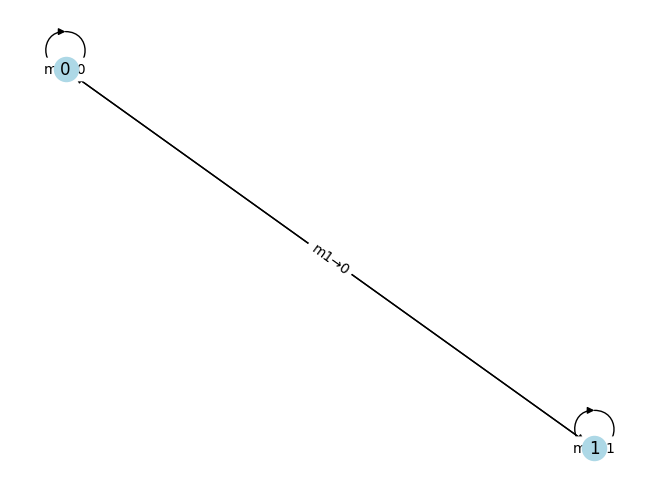

In [232]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.DiGraph()
G.add_edges_from(list(zip(src.tolist(), dst.tolist())))
pos = nx.spring_layout(G, seed=42)
nx.draw(G, pos, with_labels=True, node_color='lightblue', arrows=True)
labels = {e: f"m{e[0]}→{e[1]}" for e in G.edges()}
nx.draw_networkx_edge_labels(G, pos, edge_labels=labels)
plt.show()


In [233]:
class GCNLayer(nn.Module):

    def __init__(self, c_in, c_out):
        super().__init__()
        self.projection = nn.Linear(c_in, c_out)

    def forward(self, node_feats, adj_matrix):
        """
        Inputs:
            node_feats - Tensor with node features of shape [batch_size, num_nodes, c_in]
            adj_matrix - Batch of adjacency matrices of the graph. If there is an edge from i to j, adj_matrix[b,i,j]=1 else 0.
                         Supports directed edges by non-symmetric matrices. Assumes to already have added the identity connections.
                         Shape: [batch_size, num_nodes, num_nodes]
        """
        # Num neighbours = number of incoming edges
        num_neighbours = adj_matrix.sum(dim=-1, keepdims=True)
        node_feats = self.projection(node_feats)
        node_feats = torch.bmm(adj_matrix, node_feats)
        node_feats = node_feats / num_neighbours
        return node_feats

In [234]:
node_feats = torch.arange(8, dtype=torch.float32).view(1, 4, 2)
adj_matrix = torch.Tensor([[[1, 1, 0, 0],
                            [1, 1, 1, 1],
                            [0, 1, 1, 1],
                            [0, 1, 1, 1]]])

print("Node features:\n", node_feats)
print("\nAdjacency matrix:\n", adj_matrix)

Node features:
 tensor([[[0., 1.],
         [2., 3.],
         [4., 5.],
         [6., 7.]]])

Adjacency matrix:
 tensor([[[1., 1., 0., 0.],
         [1., 1., 1., 1.],
         [0., 1., 1., 1.],
         [0., 1., 1., 1.]]])


In [241]:
torch.tensor(edge_index).shape

torch.Size([2, 4])

In [259]:
layer = GCNLayer(c_in=39, c_out=39)
layer.projection.weight.data = torch.ones((39, 39))
layer.projection.bias.data = torch.zeros(39)

num_nodes = node_features.shape[0]
adj = torch.zeros((1, num_nodes, num_nodes))
for u, v in edges:
    adj[0, u, v] = 1  # fill in your edges

node_feats = torch.tensor(node_features, dtype=torch.float32).unsqueeze(0)  # add batch dimension

with torch.no_grad():
    out_feats = layer(node_feats, adj)
print(out_feats.shape)  # (1, num_nodes, 39)


torch.Size([1, 2, 39])


In [262]:
node_feats

tensor([[[0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          1., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 1.,
          0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0.,
          0., 0., 0., 0., 0., 1., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 1.,
          0., 0., 0., 0., 0.]]])

In [261]:
out_feats

tensor([[[5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5.,
          5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5.,
          5., 5., 5., 5., 5.],
         [5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5.,
          5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5.,
          5., 5., 5., 5., 5.]]])

In [ ]:
class SimpleMessagePassing(nn.Module):
    def __init__(self, node_dim, edge_dim, hidden_dim):
        super().__init__()

        # cretae linear projections/ transforms for the input node, edge, and message vectors
        self.node_proj = nn.Linear(in_features=node_dim, out_features=hidden_dim)
        self.edge_proj = nn.Linear(in_features=edge_dim, out_features=hidden_dim)
        self.update_proj = nn.Linear(in_features=hidden_dim, out_features=hidden_dim)

    def forward(self, node_features, edge_index, edge_attr):
        num_nodes = node_features.shape[0] # .shape should work with tensors or arrays
        num_edges = edge_index.shape[0]

        # 1. Project/ linearly transform node and edge features/ attributes
        node_proj = self.node_proj(node_features) # [num_nodes x hidden_dim]
        edge_proj = self.edge_proj(edge_attr) # [num_edges = hidden_dim]

        # 2. Initialize messages
        messages = torch.zeros_like(input=node_proj)

        # 3. For each edge (u -> v), compute messages
        src, dst = edge_index

In [117]:
x = nn.Linear(in_features = 39, out_features = 2)

In [118]:
torch.tensor(node_features[0,:]).shape[0]

39

In [119]:
x(torch.tensor(node_features[0,:]))

tensor([0.1234, 0.1414], grad_fn=<ViewBackward0>)

In [120]:
x.weight

Parameter containing:
tensor([[-0.0417,  0.0714,  0.0899, -0.1156, -0.0347, -0.0947,  0.0919, -0.0239,
         -0.0971, -0.1136, -0.1566,  0.1396,  0.1500, -0.1590, -0.0678,  0.0221,
          0.0590,  0.1515, -0.0869,  0.0308, -0.0783,  0.0721,  0.0561,  0.1279,
          0.1093,  0.1092,  0.0939, -0.1532,  0.0133,  0.0213, -0.0728,  0.0655,
         -0.0667, -0.0806,  0.1322, -0.1229, -0.0371,  0.0200, -0.0863],
        [ 0.1359,  0.1257, -0.0376,  0.0431, -0.0483, -0.1030, -0.1479, -0.0005,
         -0.0864,  0.0134, -0.1462,  0.0581, -0.0532,  0.0123,  0.0017, -0.0120,
          0.0626, -0.0356, -0.0566, -0.1012,  0.0634,  0.1535,  0.1387,  0.1313,
          0.0487, -0.1374,  0.0142,  0.1280,  0.0699, -0.0319, -0.0970,  0.1093,
          0.0017,  0.1172,  0.0898,  0.0903, -0.0809,  0.0201, -0.0988]],
       requires_grad=True)

In [125]:
torch.tensor(edge_index).shape

torch.Size([2, 4])

In [123]:
num_neighbors = torch.tensor(edge_index).sum(dim=-1, keepdims = True)
projection_layer = nn.Linear(in_features = 39, out_features = 39)
node_features_transformed = projection_layer(torch.tensor(node_features[0,:]))
node_features_transformed = torch.bmm(torch.tensor(edge_index), node_features_transformed)

RuntimeError: batch1 must be a 3D tensor

In [104]:
torch.tensor(edge_index).sum(dim=-1, keepdims=True)

tensor([[2],
        [2]])

In [ ]:
class GCNLayer(nn.Module):
    super().__init__()
    self.projection = nn.Linear(in_features = 32, out_features = 32)

    def forward(self, node_features, edge_index):
        """_summary_

        Args:
            node_features (_type_): Tensor with node features of shape [batc]
            edge_index (_type_): _description_
        """
        # number of neighbors = number of incoming edges in adjacency matrix
        num_neighbors = edge_index.sum(dim=-1, keepdims=True)
        node_features = self.projection(node_features)

In [ ]:
linear_layer = torch.nn.linear()

In [ ]:
class GraphAttentionLayer(nn.Module):
    def __init__(self, in_dim: int, out_dim: int, heads: int, edge_dim: int, dropout: float = 0.0):
        super().__init__()
        self.heads = heads
        self.out_dim = out_dim
        self.lin = nn.Linear(in_dim, out_dim * heads, bias=False)
        self.att_src = nn.Parameter(torch.Tensor(heads, out_dim))
        self.att_dst = nn.Parameter(torch.Tensor(heads, out_dim))
        self.bias = nn.Parameter(torch.Tensor(out_dim))
        self.edge_proj = nn.Linear(edge_dim, heads, bias=False)
        self.dropout = dropout
        self.reset_parameters()

    def reset_parameters(self):
        nn.init.xavier_uniform_(self.lin.weight)
        nn.init.xavier_uniform_(self.att_src)
        nn.init.xavier_uniform_(self.att_dst)
        nn.init.zeros_(self.bias)
        nn.init.xavier_uniform_(self.edge_proj.weight)

    def forward(self, x, edge_index, edge_attr):
        h = self.lin(x)
        num_nodes = h.size(0)
        h = h.view(num_nodes, self.heads, self.out_dim)
        att_src = (h * self.att_src).sum(dim=-1)
        att_dst = (h * self.att_dst).sum(dim=-1)
        src, dst = edge_index
        edge_logits = att_src[src] + att_dst[dst] + self.edge_proj(edge_attr)
        edge_logits = F.leaky_relu(edge_logits, 0.2)
        edge_alpha = edge_softmax(dst, edge_logits, num_nodes)
        edge_alpha = F.dropout(edge_alpha, p=self.dropout, training=self.training)
        out = h[src] * edge_alpha.unsqueeze(-1)
        agg = torch.zeros(num_nodes, self.heads, self.out_dim, device=x.device)
        agg.index_add_(0, dst, out)
        return agg.mean(dim=1) + self.bias